In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default") #ensures consistent graph plot

In [2]:
df = pd.read_csv("superstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [22]:
#to view no of rows and cols
df.shape

(9977, 15)

In [4]:
#to get full details
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
#to view the statistical info
df.describe()


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
#to check missing values
df.isnull().sum() #counts missing values in each column.
#isnull() gives 1 for NULL 0 NOT NULL sum() adds up so if a col calories it shows 3 --tht means there is 3 NULL values in calories

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [8]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [10]:
#Feature Engineering
df["Total_Sales"] = df["Sales"] * df["Quantity"]
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Total_Sales
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,523.9200
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2195.8200
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,29.2400
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,4787.8875
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,44.7360


In [12]:
#To see total sales per category
category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)
print(category_sales)


Category
Technology         4.080262e+06
Furniture          3.857416e+06
Office Supplies    3.547519e+06
Name: Total_Sales, dtype: float64


In [15]:
#Top 10 profitable products
df.sort_values("Profit", ascending=False)[
    ["Category", "Sub-Category","Profit"]
].head(10)


,Category,Sub-Category,Profit
6826,Technology,Copiers,8399.9760
8153,Technology,Copiers,6719.9808
4190,Technology,Copiers,5039.9856
9039,Office Supplies,Binders,4946.3700
4098,Office Supplies,Binders,4630.4755
2623,Technology,Copiers,3919.9888
509,Office Supplies,Binders,3177.4750
8488,Technology,Machines,2799.9840
7666,Technology,Copiers,2591.9568
6520,Office Supplies,Binders,2504.2216


In [17]:
#Region-wise sales
df.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)


Region
West       3.594539e+06
East       3.378520e+06
Central    2.474462e+06
South      2.037675e+06
Name: Total_Sales, dtype: float64

In [18]:
#Creating a col Order_Date
df["Order_Date"] = pd.date_range( #create a col Order_Date , date_range() create a sequence of date
    start="2025-01-01", #first date will be 1st Jan
    periods=len(df), #len(df) : counts no of rows ; so for each row there will be a corr date
    freq="D" #D=Daily increase day by day,M=Monthly,Y=Yearly
)
monthly_sales = df.groupby(df["Order_Date"].dt.month)["Total_Sales"].sum() #dt.month extracts month no 1=Jan
monthly_sales


Order_Date
1     8.836708e+05
2     7.583331e+05
3     9.684856e+05
4     8.069098e+05
5     1.199449e+06
6     9.360068e+05
7     8.020522e+05
8     8.648418e+05
9     1.317166e+06
10    1.095457e+06
11    8.039112e+05
12    1.048914e+06
Name: Total_Sales, dtype: float64

In [19]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Total_Sales,Order_Date
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,523.9200,2025-01-01
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2195.8200,2025-01-02
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,29.2400,2025-01-03
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,4787.8875,2025-01-04
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,44.7360,2025-01-05


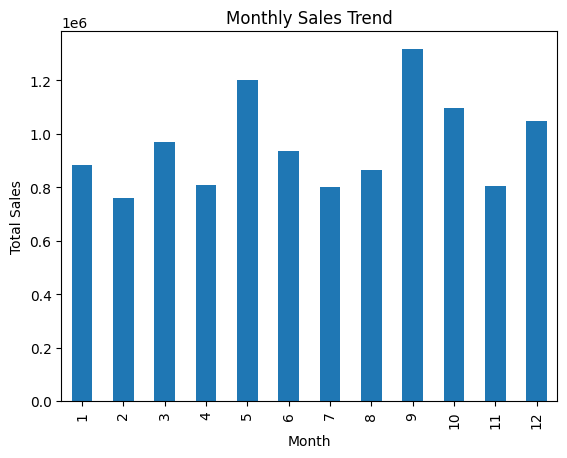

In [20]:
#Visualisation
monthly_sales.plot(kind="bar", title="Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


In [23]:
#saving cleaned data
df.to_csv("cleaned_superstore_data.csv", index=False)

In [25]:
#Key Insights
# Sales show variation across months
#Certain months outperform others, suggesting opportunities for targeted promotions.
#Synthetic date generation enabled temporal trend analysis in absence of real order dates.
